# Unlearning Project: Evaluation Analysis


We will focus on three key metrics:

    Retain Accuracy (Acc_R): Performance on the "retain set." We want this high.

    Forget Accuracy (Acc_F​): Performance on the "forget set." We want this low (ideally, near random guess).

    Test Accuracy (Acc_T​): Performance on the general test set. We want this high, similar to AccR​.

In [9]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
from pathlib import Path
from tqdm import tqdm  # <-- This is the only change
import importlib.util  # For loading config.py
# Reset DPI to a standard value (100 is good for notebooks)
plt.rcParams['figure.dpi'] = 100

print(f"Matplotlib figure.dpi reset to {plt.rcParams['figure.dpi']}")
# Set standard plotting style
sns.set_theme(style="whitegrid", context="talk")

Matplotlib figure.dpi reset to 100.0


In [15]:

spec = importlib.util.spec_from_file_location("config", "config.py")
config_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config_module)
Config = config_module.Config

pretrained_models_dir = Config.PRETRAINED_MODEL
# Use the config variables for your paths
cat_04_path = Config.CATS_04_PATH
cat_05_conservative_path = Config.CATS_05_CONSERVATIVE_PATH
cat_05_ft_conservative_path = Config.CATS_05_FT_CONSERVATIVE_PATH
cat_05_ga_extreme_path = Config.CATS_05_GA_EXTREME_PATH
cat_05_path = Config.CATS_05_PATH
cat_05_ultra_conservative_path = Config.CATS_05_ULTRA_CONSERVATIVE_PATH

dog_04_path = Config.DOGS_04_PATH
dog_05_conservative_path = Config.DOGS_05_CONSERVATIVE_PATH
dog_05_ga_path = Config.DOGS_05_GA_PATH
dog_05_rl_path = Config.DOGS_05_RL_PATH
dog_06_path = Config.DOGS_06_PATH

vehicle_05_conservative_path = Config.VEHICLES_05_CONSERVATIVE_PATH
vehicle_05_ga_path = Config.VEHICLES_05_GA_PATH


inceptionv3_03_path = Config.INCEPTIONV3_CATS_05_PATH
inceptionv3_05_path = Config.INCEPTIONV3_CATS_05_PATH

print("✓ Configuration loaded with relative paths")
print(f"✓ Working from: {Config.BASE_DIR}")

✓ Configuration loaded with relative paths
✓ Working from: /media/hdd/usr/leyla/Unlearn-Saliency


   > Found test metrics: Retain=86.23%, Forget=64.15%


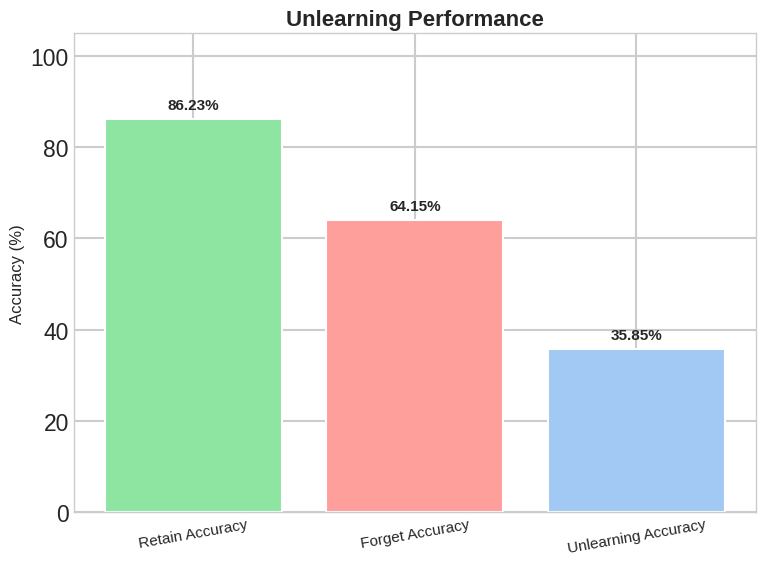

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import os

# ==============================================================================

metrics_path = cat_05_ga_extreme_path
# ==============================================================================
train_values = []
test_values = []


metrics = torch.load(metrics_path, map_location='cpu')

if 'accuracy' in metrics and isinstance(metrics['accuracy'], dict):
    acc_dict = metrics['accuracy']
    retain_test = acc_dict.get('retain', 0)
    forget_test = acc_dict.get('forget', 0)
    unlearning_test = 100.0 - forget_test
    test_values = [retain_test, forget_test, unlearning_test]
    print("   > Found test metrics: Retain={:.2f}%, Forget={:.2f}%".format(retain_test, forget_test))


# ==============================================================================

if test_values or train_values:

    palette = sns.color_palette("pastel")

    retain_color = palette[2]  
    forget_color = palette[3]  
    unlearning_color = palette[0] 

    labels = ['Retain Accuracy', 'Forget Accuracy', 'Unlearning Accuracy']
    values = test_values # Assuming we are plotting test values
    colors = [retain_color, forget_color, unlearning_color]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(labels, values, color=colors)

    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Unlearning Performance', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.xticks(fontsize=11, rotation=10)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping plot generation because no metrics were extracted.")

   > Found test metrics: Retain=77.51%, Forget=66.74%


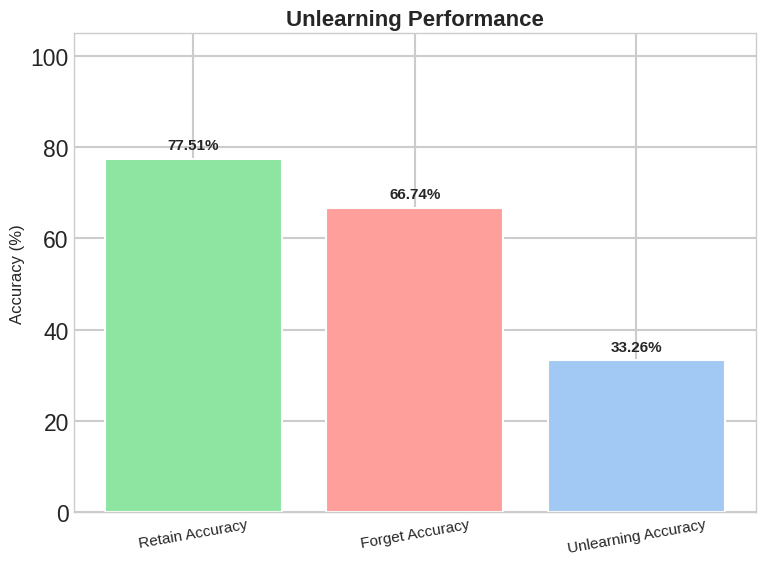

In [16]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import os

# ==============================================================================
metrics_path = inceptionv3_03_path
# ==============================================================================
train_values = []
test_values = []


metrics = torch.load(metrics_path, map_location='cpu')

if 'accuracy' in metrics and isinstance(metrics['accuracy'], dict):
    acc_dict = metrics['accuracy']
    retain_test = acc_dict.get('retain', 0)
    forget_test = acc_dict.get('forget', 0)
    unlearning_test = 100.0 - forget_test
    test_values = [retain_test, forget_test, unlearning_test]
    print("   > Found test metrics: Retain={:.2f}%, Forget={:.2f}%".format(retain_test, forget_test))


# ==============================================================================

if test_values or train_values:

    palette = sns.color_palette("pastel")

    retain_color = palette[2]  
    forget_color = palette[3]  
    unlearning_color = palette[0] 

    labels = ['Retain Accuracy', 'Forget Accuracy', 'Unlearning Accuracy']
    values = test_values # Assuming we are plotting test values
    colors = [retain_color, forget_color, unlearning_color]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(labels, values, color=colors)

    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Unlearning Performance', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.xticks(fontsize=11, rotation=10)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping plot generation because no metrics were extracted.")

   > Found test metrics: Retain=77.51%, Forget=66.74%


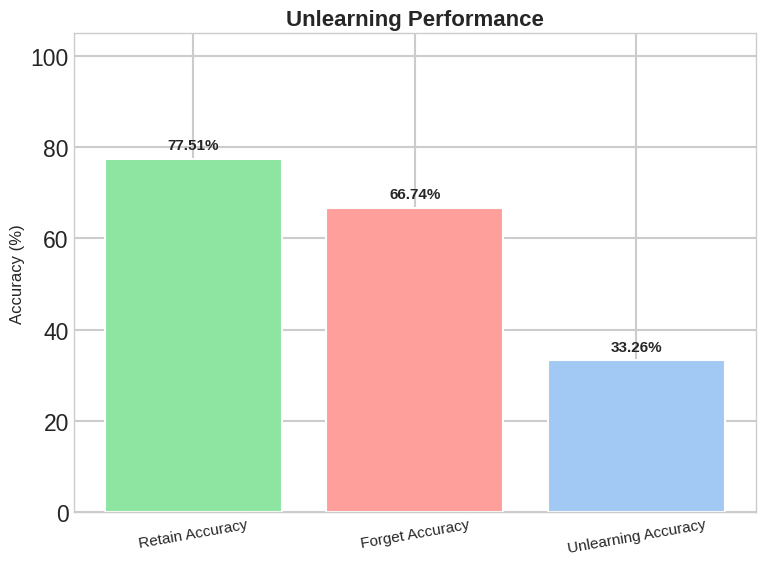

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import os

# ==============================================================================

metrics_path = inceptionv3_05_path
# ==============================================================================
train_values = []
test_values = []


metrics = torch.load(metrics_path, map_location='cpu')

if 'accuracy' in metrics and isinstance(metrics['accuracy'], dict):
    acc_dict = metrics['accuracy']
    retain_test = acc_dict.get('retain', 0)
    forget_test = acc_dict.get('forget', 0)
    unlearning_test = 100.0 - forget_test
    test_values = [retain_test, forget_test, unlearning_test]
    print("   > Found test metrics: Retain={:.2f}%, Forget={:.2f}%".format(retain_test, forget_test))


# ==============================================================================

if test_values or train_values:

    palette = sns.color_palette("pastel")

    retain_color = palette[2]  
    forget_color = palette[3]  
    unlearning_color = palette[0] 

    labels = ['Retain Accuracy', 'Forget Accuracy', 'Unlearning Accuracy']
    values = test_values # Assuming we are plotting test values
    colors = [retain_color, forget_color, unlearning_color]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(labels, values, color=colors)

    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Unlearning Performance', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.xticks(fontsize=11, rotation=10)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping plot generation because no metrics were extracted.")

In [3]:
# --- 1. SET PATH TO YOUR CONFIG FILE ---
CONFIG_FILE_PATH = "config.py" # Assumes config.py is in the same dir

if not os.path.exists(CONFIG_FILE_PATH):
    print(f"--- ‼ ERROR ‼ ---")
    print(f"Config file not found at: {CONFIG_FILE_PATH}")
    print("Please update `CONFIG_FILE_PATH` to point to your config.py")
    raise FileNotFoundError(f"Config file not found: {CONFIG_FILE_PATH}")
else:
    print(f"Loading config from: {os.path.abspath(CONFIG_FILE_PATH)}")
    spec = importlib.util.spec_from_file_location("config", CONFIG_FILE_PATH)
    config_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(config_module)
    Config = config_module.Config
    print("✅ Config object loaded successfully.")


# --- 2. DEFINE THE **NESTED** METRIC KEYS (DEFAULT) ---
# This is the structure you found: data['accuracy']['retain']
METRIC_KEYS_NESTED = {
    'retain': ('accuracy', 'retain'),
    'forget': ('accuracy', 'forget'),
    'test':   ('accuracy', 'test')
}

# --- 3. DEFINE THE **FLAT** METRIC KEYS (FOR ERRORING FILES) ---
# This is a guess for files that don't use the nested structure.
# It assumes: data['acc_retain']
METRIC_KEYS_FLAT = {
    'retain': 'acc_retain',
    'forget': 'acc_forget',
    'test':   'acc_test'
}


# --- 4. DEFINE YOUR LIST OF EXPERIMENTS (loaded from Config) ---
# "Random Forget" section has been removed.
# The "Cats Ultra Conservative" experiment now has a 'metric_keys'
# override to fix the error you were seeing.

EXPERIMENTS = [
    # Class-wise: Cats
    {'name': 'Cats 0.4', 'group': 'Cats', 'method': 'RL', 'path': Config.CATS_04_PATH},
    {'name': 'Cats Conservative 0.5', 'group': 'Cats', 'method': 'RL', 'path': Config.CATS_05_CONSERVATIVE_PATH},
    {'name': 'Cats FT Conservative 0.5', 'group': 'Cats', 'method': 'FT', 'path': Config.CATS_05_FT_CONSERVATIVE_PATH},
    {'name': 'Cats GA Extreme 0.5', 'group': 'Cats', 'method': 'GA', 'path': Config.CATS_05_GA_EXTREME_PATH},
    {'name': 'Cats 0.5', 'group': 'Cats', 'method': 'RL', 'path': Config.CATS_05_PATH},


    # Class-wise: Dogs
    {'name': 'Dogs 0.4', 'group': 'Dogs', 'method': 'RL', 'path': Config.DOGS_04_PATH},
    {'name': 'Dogs Conservative 0.5', 'group': 'Dogs', 'method': 'GA', 'path': Config.DOGS_05_CONSERVATIVE_PATH},
    {'name': 'Dogs GA 0.5', 'group': 'Dogs', 'method': 'GA', 'path': Config.DOGS_05_GA_PATH},
    {'name': 'Dogs RL 0.5', 'group': 'Dogs', 'method': 'RL', 'path': Config.DOGS_05_RL_PATH},
    {'name': 'Dogs 0.6', 'group': 'Dogs', 'method': 'RL', 'path': Config.DOGS_06_PATH},
    
    # Class-wise: Vehicles
    {'name': 'Vehicles Conservative 0.5', 'group': 'Vehicles', 'method': 'RL', 'path': Config.VEHICLES_05_CONSERVATIVE_PATH},
    {'name': 'Vehicles GA 0.5', 'group': 'Vehicles', 'method': 'GA', 'path': Config.VEHICLES_05_GA_PATH},
]


# --- 5. DEFINE DATASET-SPECIFIC CONSTANTS ---
RANDOM_GUESS_ACC = 0.005  # For Tiny ImageNet (1/200 classes)
IDEAL_RETAIN_ACC = 0.95 # e.g., 1.0, or your pretrained model's accuracy

Loading config from: /media/hdd/usr/leyla/Unlearn-Saliency/notebooks/config.py
✅ Config object loaded successfully.


In [4]:
def get_nested_key_safe(data_dict, key_path, default=None):
    """Safely accesses a key, handling nested (tuples) and flat (strings) paths."""
    if isinstance(key_path, tuple):
        current_val = data_dict
        try:
            for key in key_path:
                current_val = current_val[key]
            return current_val
        except (KeyError, TypeError):
            return default
    else:
        return data_dict.get(key_path, default)

def load_evaluation_data(experiments_list, default_metric_keys):
    """Loads all experiment data and normalizes scores to 0-1 range."""
    print(f"Loading data for {len(experiments_list)} experiments...")
    all_results = []

    for experiment in tqdm(experiments_list, desc="Processing files"):
        f_path = experiment['path']
        if not os.path.exists(f_path):
            print(f"Warning: Skipping (File not found): {f_path}")
            continue
            
        try:
            data = torch.load(f_path, map_location='cpu')
            result_row = {
                'name': experiment['name'],
                'group': experiment['group'],
                'method': experiment['method'],
                'full_path': f_path
            }
            metric_keys = experiment.get('metric_keys', default_metric_keys)
            
            retain_val = get_nested_key_safe(data, metric_keys['retain'])
            forget_val = get_nested_key_safe(data, metric_keys['forget'])
            test_val = get_nested_key_safe(data, metric_keys.get('test'))

            if retain_val is None or forget_val is None:
                print(f"Error: Metric keys not found in {f_path}. Skipping.")
                continue
            if test_val is None:
                test_val = 0.0
            
            result_row['retain_acc'] = retain_val
            result_row['forget_acc'] = forget_val
            result_row['test_acc'] = test_val
            all_results.append(result_row)
            
        except Exception as e:
            print(f"Error loading file {f_path}: {e}")
            
    if not all_results:
        print("\n--- WARNING ---")
        print("No data was loaded.")
        return pd.DataFrame()

    df = pd.DataFrame(all_results)
    
    # --- !!! THIS IS THE FIX !!! ---
    # Convert all scores to numeric and normalize them from 0-100 to 0-1
    print("\nNormalizing scores (dividing by 100)...")
    acc_cols = ['retain_acc', 'forget_acc', 'test_acc']
    for col in acc_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col])
            # Check if any value is > 1.0, which implies 0-100 scale
            if (df[col] > 1.0).any():
                print(f"  > Normalizing '{col}'...")
                df[col] = df[col] / 100.0
    
    return df

# --- Run the data loading function ---
df_results = load_evaluation_data(EXPERIMENTS, METRIC_KEYS_NESTED)

if not df_results.empty:
    print("\n✅ Data loaded and normalized successfully!")
else:
    print("\n❌ No data was loaded. Please check your configuration.")

Loading data for 12 experiments...


Processing files: 100%|██████████| 12/12 [00:00<00:00, 6129.04it/s]


Normalizing scores (dividing by 100)...
  > Normalizing 'retain_acc'...
  > Normalizing 'forget_acc'...
  > Normalizing 'test_acc'...

✅ Data loaded and normalized successfully!


In [7]:
# --- Set Pandas display options to show ALL rows and columns ---
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

if 'df_results' in locals() and not df_results.empty:
    print("\n--- Displaying ALL Experiment Results ---")
    display(df_results)
else:
    print("\n❌ No data loaded (df_results is empty). Run Cell 3 first.")

# --- Reset display options to default ---
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')


--- Displaying ALL Experiment Results ---


,name,group,method,full_path,retain_acc,forget_acc,test_acc
0,Cats 0.4,Cats,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.999776,1.000000,0.6620
1,Cats Conservative 0.5,Cats,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.999786,1.000000,0.6576
2,Cats FT Conservative 0.5,Cats,FT,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.999776,1.000000,0.6508
3,Cats GA Extreme 0.5,Cats,GA,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.862265,0.641500,0.5328
4,Cats 0.5,Cats,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.999786,1.000000,0.6648
5,Dogs 0.4,Dogs,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.644670,0.694333,0.4840
6,Dogs Conservative 0.5,Dogs,GA,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.967959,0.759333,0.5868
7,Dogs GA 0.5,Dogs,GA,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.005155,0.000000,0.0050
8,Dogs RL 0.5,Dogs,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.867670,0.810667,0.5544
9,Dogs 0.6,Dogs,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,0.879320,0.824000,0.5646


   > Found test metrics: Retain=96.80%, Forget=75.93%


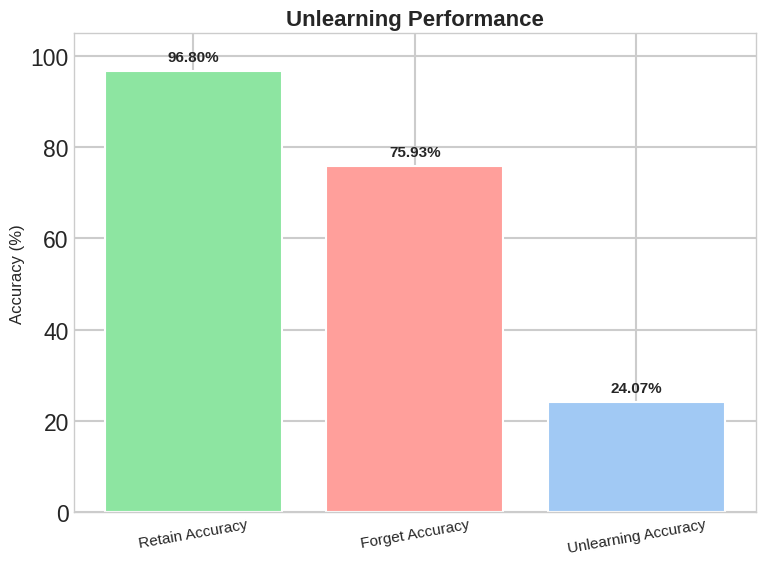

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import os

# ==============================================================================

metrics_path = dog_05_conservative_path
# ==============================================================================
train_values = []
test_values = []


metrics = torch.load(metrics_path, map_location='cpu')

if 'accuracy' in metrics and isinstance(metrics['accuracy'], dict):
    acc_dict = metrics['accuracy']
    retain_test = acc_dict.get('retain', 0)
    forget_test = acc_dict.get('forget', 0)
    unlearning_test = 100.0 - forget_test
    test_values = [retain_test, forget_test, unlearning_test]
    print("   > Found test metrics: Retain={:.2f}%, Forget={:.2f}%".format(retain_test, forget_test))


# ==============================================================================

if test_values or train_values:

    palette = sns.color_palette("pastel")

    retain_color = palette[2]  
    forget_color = palette[3]  
    unlearning_color = palette[0] 

    labels = ['Retain Accuracy', 'Forget Accuracy', 'Unlearning Accuracy']
    values = test_values # Assuming we are plotting test values
    colors = [retain_color, forget_color, unlearning_color]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(labels, values, color=colors)

    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Unlearning Performance', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 105)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.xticks(fontsize=11, rotation=10)
    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping plot generation because no metrics were extracted.")

In [9]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


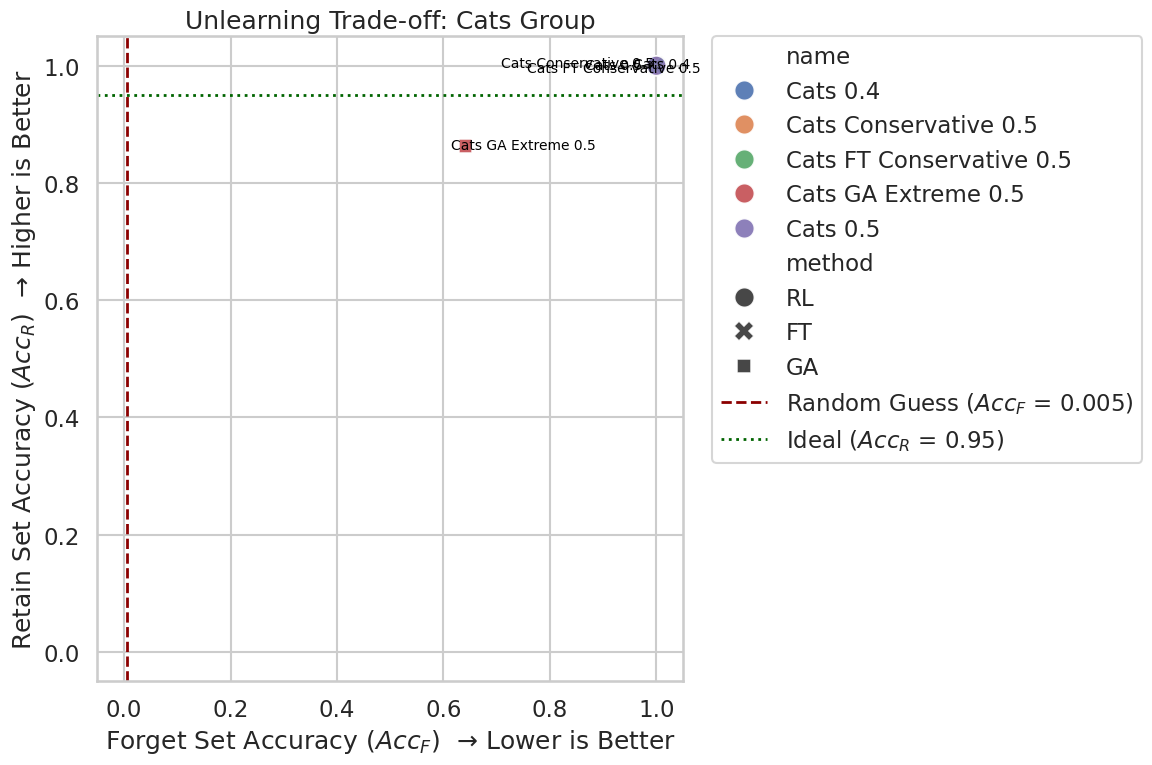

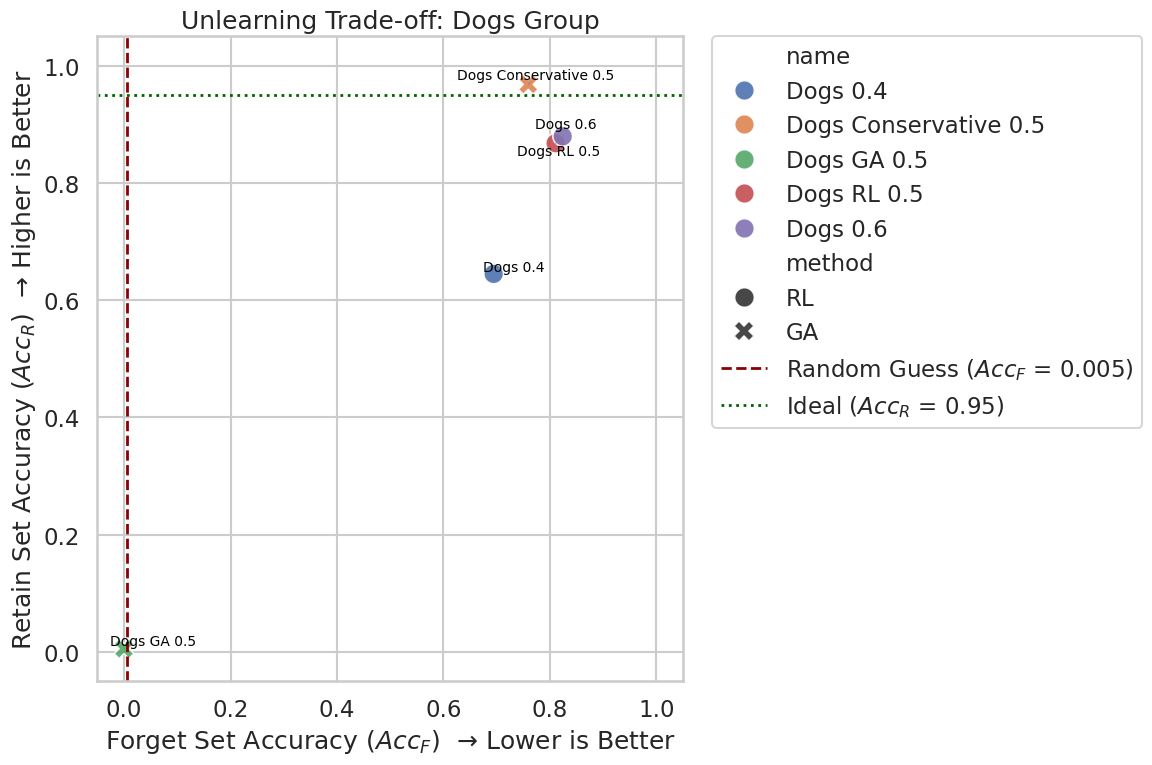

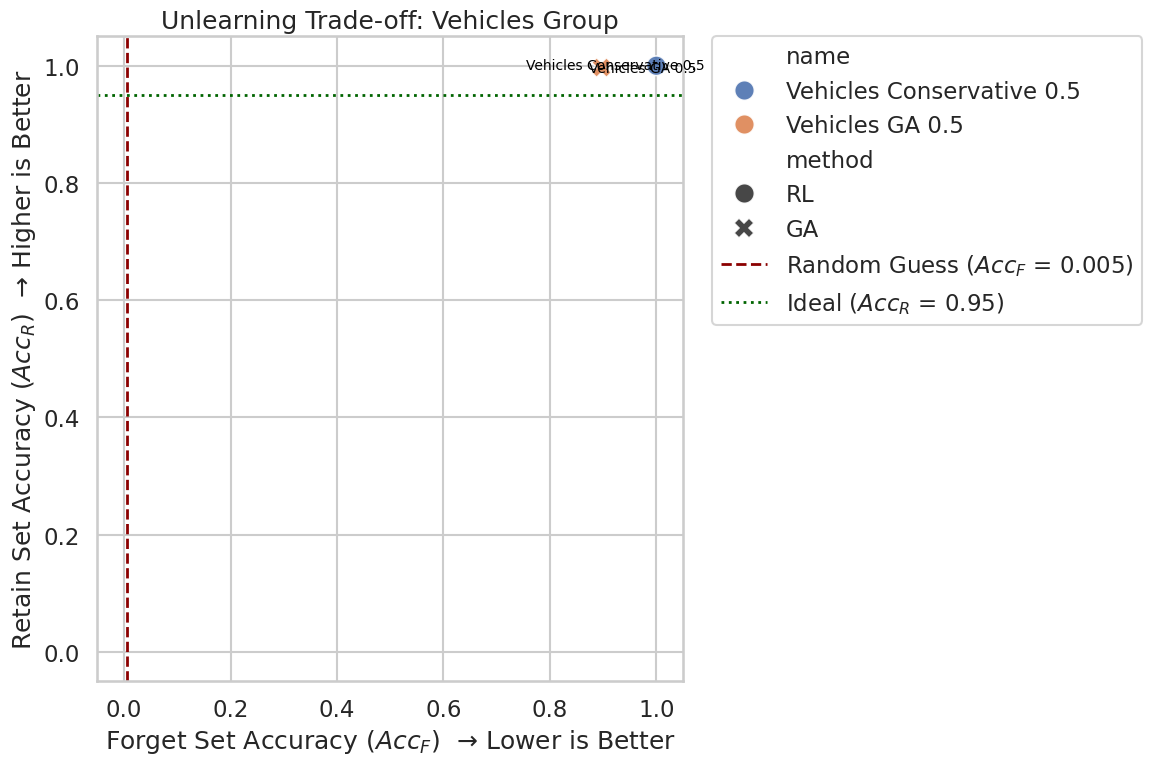

In [6]:
from adjustText import adjust_text # For non-overlapping labels

def create_tradeoff_plot(data, title):
    """
    Helper function to create a single trade-off scatter plot.
    """
    plt.figure(figsize=(10, 8))
    
    # We use 'name' for the hue so each experiment has a unique color
    plot = sns.scatterplot(
        data=data,
        x='forget_acc',
        y='retain_acc',
        hue='name',
        style='method',
        s=200,
        alpha=0.9
    )
    
    # --- Context Lines ---
    plt.axvline(
        x=RANDOM_GUESS_ACC, 
        color="darkred",
        linestyle='--', 
        lw=2,
        label=f'Random Guess ($Acc_F$ = {RANDOM_GUESS_ACC})'
    )
    plt.axhline(
        y=IDEAL_RETAIN_ACC, 
        color="darkgreen",
        linestyle=':', 
        lw=2,
        label=f'Ideal ($Acc_R$ = {IDEAL_RETAIN_ACC})'
    )
    
    # --- Annotate points ---
    texts = []
    for i in range(data.shape[0]):
        row = data.iloc[i]
        texts.append(
            plt.text(
                x=row['forget_acc'],
                y=row['retain_acc'],
                s=row['name'],
                fontdict=dict(color='black', size=10)
            )
        )
    
    # Fix overlapping labels
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    # --- Final Touches ---
    plt.title(title)
    plt.xlabel('Forget Set Accuracy ($Acc_F$)  → Lower is Better')
    plt.ylabel('Retain Set Accuracy ($Acc_R$)  → Higher is Better')
    
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout()
    plt.subplots_adjust(right=0.7) # Make room for legend
    plt.show()

# --- Main execution ---
if 'df_results' in locals() and not df_results.empty:
    
    # Get the 'Pretrained' baseline row (if it exists)
    baseline_df = df_results[df_results['group'] == 'Baseline']
    
    # --- Plot 1: Cats ---
    cats_df = df_results[df_results['group'] == 'Cats']
    cats_plot_df = pd.concat([baseline_df, cats_df])
    create_tradeoff_plot(cats_plot_df, 'Unlearning Trade-off: Cats Group')
    
    # --- Plot 2: Dogs ---
    dogs_df = df_results[df_results['group'] == 'Dogs']
    dogs_plot_df = pd.concat([baseline_df, dogs_df])
    create_tradeoff_plot(dogs_plot_df, 'Unlearning Trade-off: Dogs Group')
    
    # --- Plot 3: Vehicles ---
    vehicles_df = df_results[df_results['group'] == 'Vehicles']
    vehicles_plot_df = pd.concat([baseline_df, vehicles_df])
    create_tradeoff_plot(vehicles_plot_df, 'Unlearning Trade-off: Vehicles Group')

else:
    print("DataFrame is empty. Skipping plot 1.")

In [7]:
if 'df_results' in locals() and not df_results.empty:
    id_vars = ['name', 'group', 'method', 'full_path']
    
    df_melted = df_results.melt(
        id_vars=id_vars,
        value_vars=['retain_acc', 'forget_acc', 'test_acc'],
        var_name='metric_type',
        value_name='accuracy'
    )
    
    df_melted['metric_type'] = df_melted['metric_type'].map({
        'retain_acc': 'Retain Acc ($Acc_R$)',
        'forget_acc': 'Forget Acc ($Acc_F$)',
        'test_acc':   'Test Acc ($Acc_T$)',
    })

    print("--- Melted DataFrame Head ---")
    display(df_melted.head())
else:
    print("DataFrame is empty. Skipping data melt.")

--- Melted DataFrame Head ---


,name,group,method,full_path,metric_type,accuracy
0,Cats 0.4,Cats,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,Retain Acc ($Acc_R$),0.999776
1,Cats Conservative 0.5,Cats,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,Retain Acc ($Acc_R$),0.999786
2,Cats FT Conservative 0.5,Cats,FT,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,Retain Acc ($Acc_R$),0.999776
3,Cats GA Extreme 0.5,Cats,GA,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,Retain Acc ($Acc_R$),0.862265
4,Cats 0.5,Cats,RL,/media/hdd/usr/leyla/Unlearn-Saliency/experime...,Retain Acc ($Acc_R$),0.999786


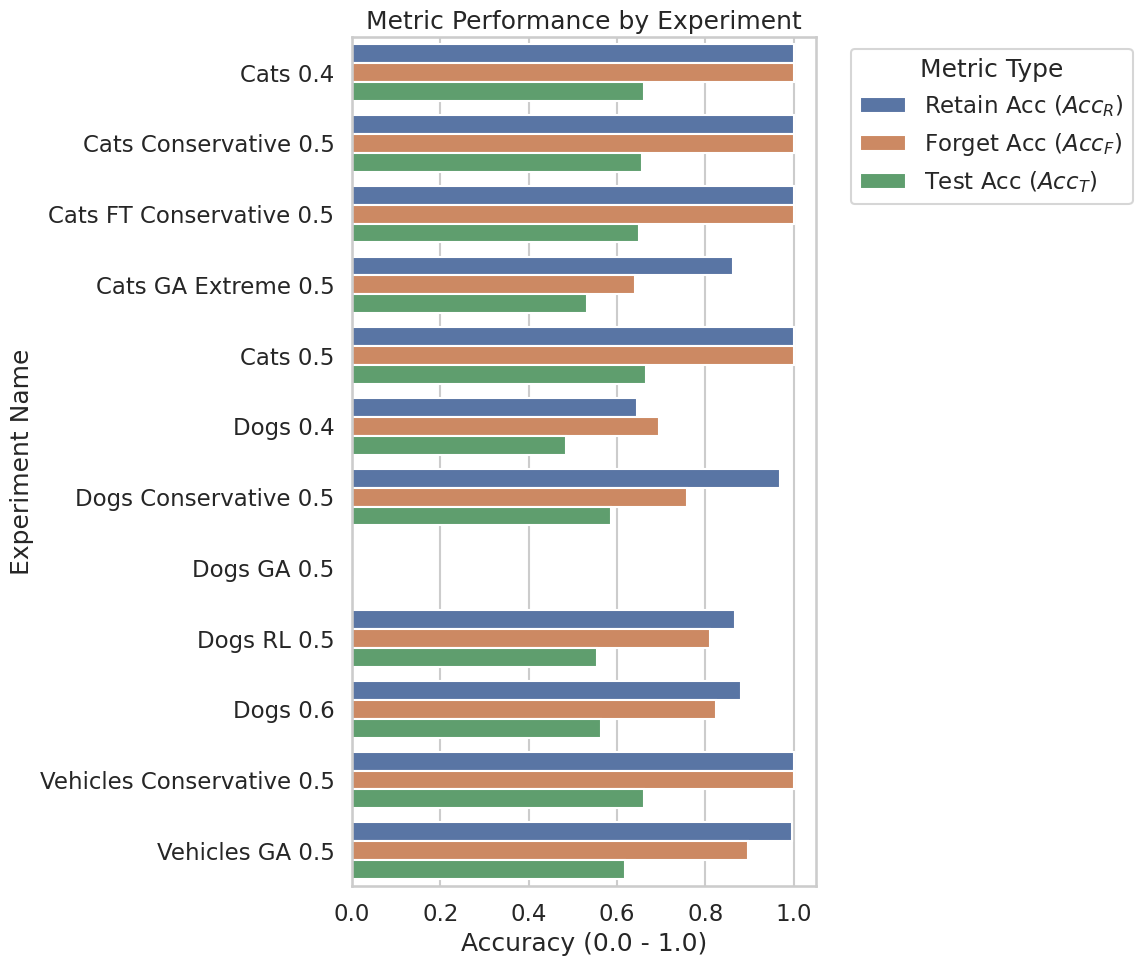

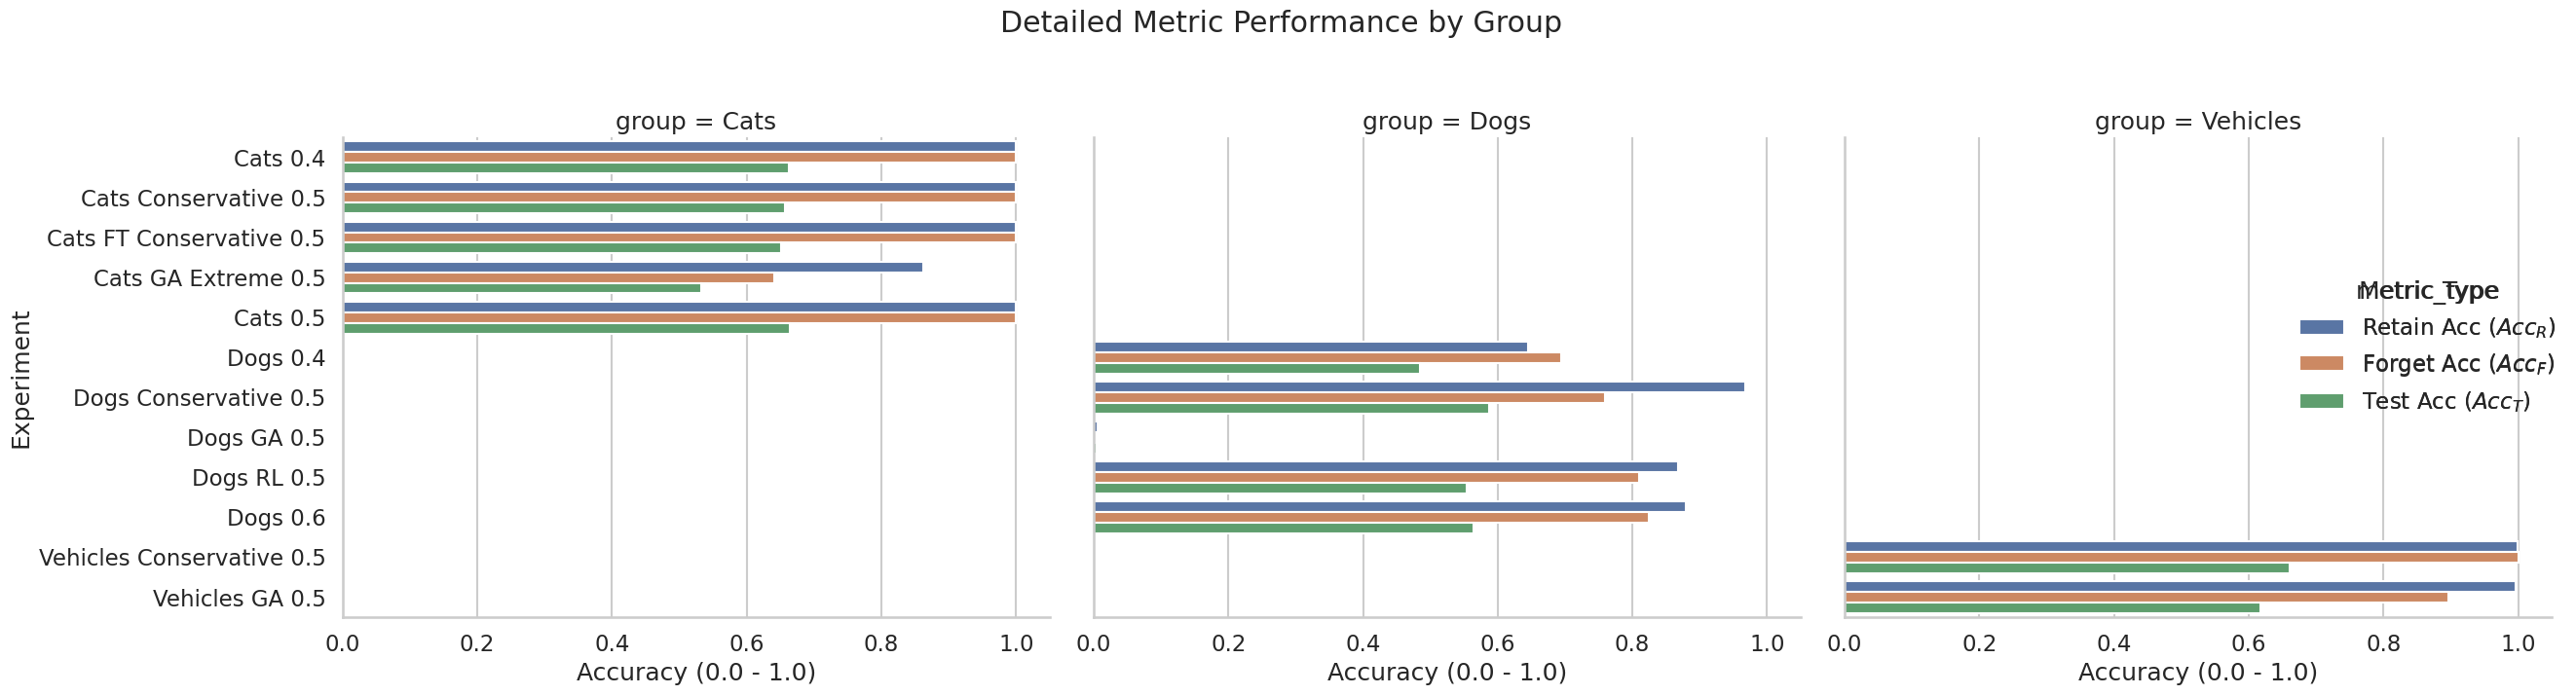

In [8]:
if 'df_melted' in locals() and not df_melted.empty:
    
    # --- Plot 1: Horizontal Bar Plot ---
    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=df_melted,
        x='accuracy',
        y='name',       # Swapped x and y
        hue='metric_type',
        orient='h'      # Set orientation to horizontal
    )
    plt.title('Metric Performance by Experiment')
    plt.xlabel('Accuracy (0.0 - 1.0)') # Updated label
    plt.ylabel('Experiment Name')
    plt.legend(title='Metric Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Faceted Plot (Also horizontal) ---
    g = sns.catplot(
        data=df_melted,
        x='accuracy',    # Swapped
        y='name',        # Swapped
        hue='metric_type',
        col='group',
        kind='bar',
        orient='h',    # Set orientation to horizontal
        height=7,
        aspect=1,
        sharex=True,
        sharey=True
    )
    g.fig.suptitle('Detailed Metric Performance by Group', y=1.03)
    g.set_axis_labels('Accuracy (0.0 - 1.0)', 'Experiment') # Updated label
    g.add_legend(title='Metric Type')
    plt.tight_layout()
    plt.show()

else:
    print("Melted DataFrame is empty or does not exist. Skipping plots.")